In [1]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from fullmodeltrain.instancepipeline import get_data_loaders
from fullmodeltrain.finalfulltrain import EarthquakeCNN, evaluate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = PROJECT_ROOT / "fullmodeltrain" / "data" / "best_model_full.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model = EarthquakeCNN().to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()




EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [4]:
import torch
import numpy as np
import pandas as pd
TARGET_MEAN = 2.28802128052746
train_loader, val_loader, test_loader = get_data_loaders()
all_predictions = []
all_targets = []
model.eval()
with torch.no_grad():
    for waveforms,magnitudes in test_loader:
        waveforms,magnitudes = waveforms.to(device), magnitudes.to(device)
        predictions = model(waveforms).squeeze(-1) 
        magnitudes = magnitudes + TARGET_MEAN
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())
results = pd.DataFrame({
    "true_magnitude": np.array(all_targets),
    "predicted_magnitude": np.array(all_predictions)
})


In [5]:
print(results[["true_magnitude", "predicted_magnitude"]].mean())

true_magnitude         2.217452
predicted_magnitude    2.006001
dtype: float32


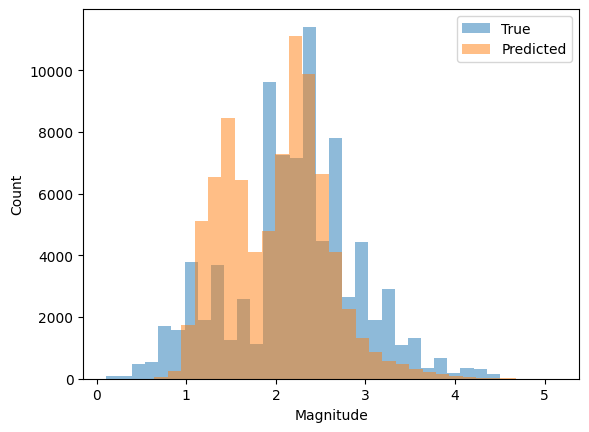

In [6]:
import matplotlib.pyplot as plt

plt.hist(results["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [7]:
results["error"] = (
    results["predicted_magnitude"]
    - results["true_magnitude"]
)

results["bin"] = pd.cut(
    results["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6],
    right=False
)

results.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"[0, 1)",4443,0.584556,0.542520
"[1, 2)",15919,0.152604,0.131199
"[2, 3)",51082,-0.261649,-0.203939
"[3, 4)",10339,-0.777493,-0.725244
"[4, 5)",986,-1.139990,-1.061781


In [46]:
print((results["true_magnitude"] > 2).count())
print((results["true_magnitude"] < 2).count())

82769
82769


In [47]:
results["error"] = (
    results["predicted_magnitude"] -
    results["true_magnitude"]
)
for low in range(6):
    mask = (
        (results["true_magnitude"] >= low) &
        (results["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results.loc[mask, "error"].abs().mean(),
        "bias =", results.loc[mask, "error"].mean()
    )

0-1 count = 4443 MAE = 0.585778 bias = 0.58455646
1-2 count = 15919 MAE = 0.3187551 bias = 0.15260401
2-3 count = 51082 MAE = 0.40260017 bias = -0.26164874
3-4 count = 10339 MAE = 0.8108569 bias = -0.7774927
4-5 count = 986 MAE = 1.1578236 bias = -1.1399901
5-6 count = 0 MAE = nan bias = nan


In [1]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from fullmodeltrain.instancepipeline import get_data_loaders
from fullmodeltrain.finalfulltrain import EarthquakeCNN, evaluate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path2 = PROJECT_ROOT / "fullmodeltrain" / "data" / "best_model_fullabovemean.pth"

checkpoint2 = torch.load(checkpoint_path2, map_location=device)
model2 = EarthquakeCNN().to(device)

model2.load_state_dict(checkpoint2["model_state_dict"])

model2.eval()

EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [2]:
train_loader, val_loader, test_loader = get_data_loaders()
import pandas as pd

In [3]:
all_predictions = []
all_targets = []

model2.eval()
TARGET_MEAN = 2.28802128052746
with torch.no_grad():
    for waveforms, magnitudes in test_loader:
        waveforms = waveforms.to(device)
        magnitudes = magnitudes.to(device)

        # model predicts centered magnitude
        predictions = model2(waveforms).squeeze(-1)

        # convert BOTH back to actual magnitude
        
        predictions = predictions + TARGET_MEAN
        magnitudes = magnitudes + TARGET_MEAN
        

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())

results2 = pd.DataFrame({
    "true_magnitude": all_targets,
    "predicted_magnitude": all_predictions
})

In [4]:
print(results2["true_magnitude"].describe())
print(results2["predicted_magnitude"].describe())

count    82769.000000
mean         2.217452
std          0.714146
min          0.100000
25%          2.000000
50%          2.200000
75%          2.600000
max          4.500000
Name: true_magnitude, dtype: float64
count    82769.000000
mean         2.185344
std          0.519095
min          0.494141
25%          1.906850
50%          2.235381
75%          2.483610
max          5.357731
Name: predicted_magnitude, dtype: float64


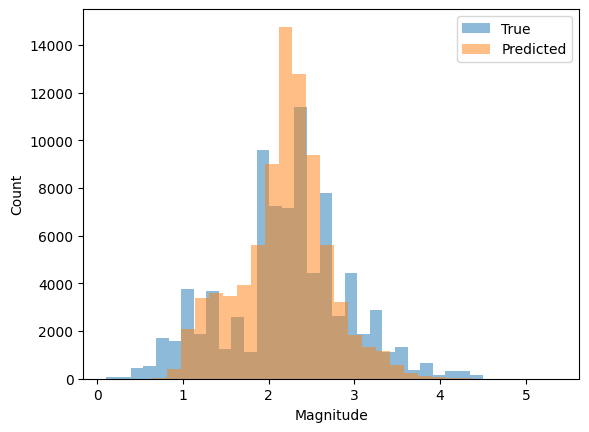

In [5]:
import matplotlib.pyplot as plt

plt.hist(results2["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results2["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [6]:
results2["error"] = (
    results2["predicted_magnitude"]
    - results2["true_magnitude"]
)

results2["bin"] = pd.cut(
    results2["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6]
)

results2.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"(0, 1]",6130,0.596250,0.526393
"(1, 2]",22281,0.218997,0.207368
"(2, 3]",45138,-0.117330,-0.092873
"(3, 4]",8407,-0.608214,-0.588228
"(4, 5]",813,-0.962830,-0.856029


In [57]:
results2["error"] = (
    results2["predicted_magnitude"] -
    results2["true_magnitude"]
)
for low in range(6):
    mask = (
        (results2["true_magnitude"] >= low) &
        (results2["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results2.loc[mask, "error"].abs().mean(),
        "bias =", results2.loc[mask, "error"].mean()
    )

0-1 count = 4443 MAE = 0.65264213 bias = 0.65205985
1-2 count = 15919 MAE = 0.37170908 bias = 0.2979407
2-3 count = 51082 MAE = 0.27018613 bias = -0.067263454
3-4 count = 10339 MAE = 0.6038063 bias = -0.5729693
4-5 count = 986 MAE = 0.9551345 bias = -0.95107496
5-6 count = 0 MAE = nan bias = nan


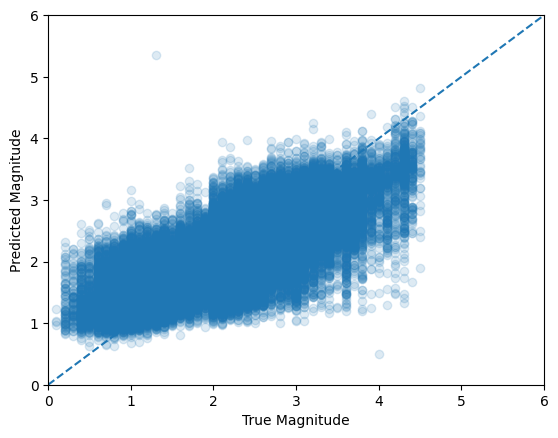

In [58]:
plt.scatter(
    results2["true_magnitude"],
    results2["predicted_magnitude"],
    alpha=0.15
)

plt.plot([0, 6], [0, 6], "--")

plt.xlabel("True Magnitude")
plt.ylabel("Predicted Magnitude")
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.show()

In [8]:
results2["error"].count()

np.int64(82769)

In [12]:
(results2["error"] < 0.5).sum()

np.int64(73699)

In [14]:
bin4 = results2[results2["true_magnitude"] > 4]

In [18]:
bin4["error"].count()

np.int64(813)

In [17]:
(bin4["error"] < 0.3).sum()

np.int64(810)

In [ ]:
results2.to_csv("nonweightedmean.csv")

NameError: name 'results' is not defined

In [19]:
import torch
import pandas as pd
import numpy as np


def evaluate_model_by_bins(
    model,
    dataloader,
    device,
    target_mean
):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for waveforms, magnitudes in dataloader:

            waveforms = waveforms.to(
                device,
                non_blocking=True
            )

            magnitudes = magnitudes.to(
                device,
                non_blocking=True
            )

            predictions = model(
                waveforms
            ).squeeze(-1)

            # Convert both back to actual magnitude scale
            actual_predictions = (
                predictions + target_mean
            )

            actual_magnitudes = (
                magnitudes + target_mean
            )

            all_predictions.append(
                actual_predictions.cpu()
            )

            all_targets.append(
                actual_magnitudes.cpu()
            )


    all_predictions = torch.cat(
        all_predictions
    ).numpy()

    all_targets = torch.cat(
        all_targets
    ).numpy()


    results = pd.DataFrame({
        "magnitude": all_targets,
        "prediction": all_predictions
    })


    results["error"] = (
        results["prediction"]
        - results["magnitude"]
    )

    results["absolute_error"] = (
        results["error"].abs()
    )


    bins = [
        0,
        1,
        2,
        3,
        4,
        5,
        6
    ]

    labels = [
        "0-1",
        "1-2",
        "2-3",
        "3-4",
        "4-5",
        "5-6"
    ]

    results["bin"] = pd.cut(
        results["magnitude"],
        bins=bins,
        labels=labels,
        right=True,
        include_lowest=True
    )


    print("\nOverall")

    overall_mae = (
        results["absolute_error"].mean()
    )

    overall_bias = (
        results["error"].mean()
    )

    overall_rmse = np.sqrt(
        np.mean(
            results["error"] ** 2
        )
    )

    accuracy_02 = (
        results["absolute_error"] <= 0.2
    ).mean() * 100


    print(
        f"MAE = {overall_mae:.6f}"
    )

    print(
        f"RMSE = {overall_rmse:.6f}"
    )

    print(
        f"Bias = {overall_bias:.6f}"
    )

    print(
        f"Accuracy ±0.2 = "
        f"{accuracy_02:.2f}%"
    )


    print("\nBy magnitude bin")

    bin_results = []

    for label in labels:

        subset = results[
            results["bin"] == label
        ]

        count = len(subset)

        if count == 0:

            mae = np.nan
            rmse = np.nan
            bias = np.nan

        else:

            mae = (
                subset["absolute_error"].mean()
            )

            rmse = np.sqrt(
                np.mean(
                    subset["error"] ** 2
                )
            )

            bias = (
                subset["error"].mean()
            )


        bin_results.append({
            "bin": label,
            "count": count,
            "MAE": mae,
            "RMSE": rmse,
            "bias": bias
        })


        print(
            f"{label} "
            f"count = {count} "
            f"MAE = {mae:.6f} "
            f"RMSE = {rmse:.6f} "
            f"bias = {bias:.6f}"
        )


    bin_results = pd.DataFrame(
        bin_results
    )

    return results, bin_results

In [20]:

weighted_results, weighted_bins = evaluate_model_by_bins(
    model2,
    test_loader,
    device,
    TARGET_MEAN
)


Overall
MAE = 0.360076
RMSE = 0.480133
Bias = -0.032109
Accuracy ±0.2 = 38.60%

By magnitude bin
0-1 count = 6130 MAE = 0.598162 RMSE = 0.712621 bias = 0.596250
1-2 count = 22281 MAE = 0.325141 RMSE = 0.414707 bias = 0.218997
2-3 count = 45138 MAE = 0.282858 RMSE = 0.376756 bias = -0.117330
3-4 count = 8407 MAE = 0.634884 RMSE = 0.751725 bias = -0.608214
4-5 count = 813 MAE = 0.967754 RMSE = 1.096680 bias = -0.962830
5-6 count = 0 MAE = nan RMSE = nan bias = nan
